In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import os
import glob

In [3]:
# csv file paths
listening_log_path = '/content//drive//MyDrive//University of Liverpool//MSc Project//Test Set/'
track_features_path = '/content//drive//MyDrive//University of Liverpool//MSc Project//Track Features/'

track_features_csvs = glob.glob(track_features_path + '*.csv')
testset_prehist_hists = glob.glob(listening_log_path + 'log_pre*.csv')

In [4]:
# Create listen log dataframes
listen_log_df = pd.read_csv(testset_prehist_hists[0], nrows=1500)

# Create an empty list to hold the track features dataframes
track_features_dfs = []

# Loop through each file path and read the CSV file
for csv_file in track_features_csvs:
    print(f"Loading {csv_file}")
    df = pd.read_csv(csv_file)
    track_features_dfs.append(df)

# Concatenate all dataframes into a single dataframe
track_features_df = pd.concat(track_features_dfs, ignore_index=True)

Loading /content//drive//MyDrive//University of Liverpool//MSc Project//Track Features/tf_000000000002.csv
Loading /content//drive//MyDrive//University of Liverpool//MSc Project//Track Features/tf_000000000003.csv
Loading /content//drive//MyDrive//University of Liverpool//MSc Project//Track Features/tf_000000000000.csv
Loading /content//drive//MyDrive//University of Liverpool//MSc Project//Track Features/tf_000000000001.csv


In [5]:
track_features_df.columns

Index(['track_id', 'track_uri', 'track_name', 'artist', 'duration',
       'release_date_estimate', 'us_popularity_estimate', 'album_name',
       'acousticness', 'beat_strength', 'bounciness', 'danceability',
       'dyn_range_mean', 'energy', 'flatness', 'instrumentalness', 'key',
       'liveness', 'loudness', 'mechanism', 'mode', 'organism', 'speechiness',
       'tempo', 'time_signature', 'valence', 'acoustic_vector_0',
       'acoustic_vector_1', 'acoustic_vector_2', 'acoustic_vector_3',
       'acoustic_vector_4', 'acoustic_vector_5', 'acoustic_vector_6',
       'acoustic_vector_7'],
      dtype='object')

In [6]:
track_features_df

,track_id,track_uri,track_name,artist,duration,release_date_estimate,us_popularity_estimate,album_name,acousticness,beat_strength,...,time_signature,valence,acoustic_vector_0,acoustic_vector_1,acoustic_vector_2,acoustic_vector_3,acoustic_vector_4,acoustic_vector_5,acoustic_vector_6,acoustic_vector_7
0,t_b725b25f-7691-4965-a8b0-e93489e8409d,spotify:track:0j62CgBbEmggGSCIDqkaSL,Stars Fell On Alabama,Jimmy Buffett,257.906677,1981,99.068916,Coconut Telegraph,0.422056,0.379351,...,3,0.310228,0.037595,-0.334169,0.169926,0.226131,0.581179,-0.090957,-0.328792,-0.812499
1,t_84dc94ad-b3d9-4f96-86f7-3199d3fb9a7b,spotify:track:0pYIbG6swaHaf4oTvZnRfQ,Compliment Your Soul,Dan Croll,181.846085,2013-01-01,99.787592,Sweet Disarray,0.000435,0.317921,...,3,0.546828,0.053556,0.135025,-0.115911,-0.548019,0.107116,0.232197,-0.403506,0.045631
2,t_723dd57f-4a6c-4528-8e09-d543c4033913,spotify:track:4l5X8j58ly0y9WBUhgMrR9,Woodgrain,DJAO,250.013336,2014-10-28,93.628713,DJAO,0.921661,0.397871,...,4,0.060216,-0.004748,-0.085217,-0.008377,-0.141654,-0.378057,0.123196,-0.134595,0.491316
3,t_34f6c173-e631-4999-b0fe-c4a347e235ba,spotify:track:3DkWC9q2TuIvsUjnAsIfyZ,Who Is Jesus?,The Brilliance,167.675964,2017-01-27,99.309987,All Is Not Lost,0.391991,0.330360,...,3,0.395950,0.144196,0.207172,-0.110625,-0.634107,0.146147,0.232993,-0.437063,-0.181432
4,t_23f3080a-c7fc-455b-8ff9-3e91ff8025ba,spotify:track:0IiJZaPiTEMgTGAPG8Cfh5,From the Ashes,Chris Trapper,149.586670,2013-10-17,92.446496,Technicolor,0.994482,0.294483,...,3,0.200294,0.640660,-0.485287,-0.215626,-0.010791,-0.461914,0.000900,0.004486,0.214457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3706383,t_af9c1b84-a090-491e-b6fc-195483529e85,spotify:track:4pblstqAoT2zjdERJdECwl,Persist,All India Radio,213.240005,2008-06-11,95.276987,Fall,0.039727,0.478646,...,4,0.300223,0.315772,0.010739,-0.152094,-0.527684,0.134812,0.172488,-0.297218,-0.207108
3706384,t_455fccfe-9ee3-47f4-88ea-fe92a8978733,spotify:track:1OS1CHppoO1jLRvmveXvtr,Red Alert 3 Theme - Soviet March,James Hannigan,167.506668,2009-08-04,99.830405,Command & Conquer: Red Alert 3,0.278012,0.296534,...,4,0.528701,0.393510,-0.322555,-0.372900,0.266250,-0.134675,-0.259413,0.293703,0.045560
3706385,t_b8d30514-b713-402c-9cb4-20d1bd694a52,spotify:track:7eQ4qq3kebOhe3lg8GdvP8,Into the Mist 2,Lightning Bolt,201.600006,2001,96.730584,Ride the Skies,0.005758,0.146130,...,4,0.137848,0.191759,-0.072551,-0.430788,-0.072750,0.154501,-0.009769,-0.138522,0.479407
3706386,t_72cd8e40-dbf5-44f1-a9cd-15a04f4ab0a2,spotify:track:50A7ZmR9b8yhGXIMkXQIxZ,Na Na Na,The Draft,180.893326,2007-03-20,96.033625,The Draft Digital EP,0.000146,0.282496,...,4,0.812083,0.170835,0.261984,-0.417902,-0.548733,0.823363,0.159150,-0.410235,0.040239


In [7]:
listen_log_df.columns

Index(['session_id', 'session_position', 'session_length', 'track_id_clean',
       'skip_1', 'skip_2', 'skip_3', 'not_skipped', 'context_switch',
       'no_pause_before_play', 'short_pause_before_play',
       'long_pause_before_play', 'hist_user_behavior_n_seekfwd',
       'hist_user_behavior_n_seekback', 'hist_user_behavior_is_shuffle',
       'hour_of_day', 'date', 'premium', 'context_type',
       'hist_user_behavior_reason_start', 'hist_user_behavior_reason_end'],
      dtype='object')

In [8]:
listen_log_df

,session_id,session_position,session_length,track_id_clean,skip_1,skip_2,skip_3,not_skipped,context_switch,no_pause_before_play,...,long_pause_before_play,hist_user_behavior_n_seekfwd,hist_user_behavior_n_seekback,hist_user_behavior_is_shuffle,hour_of_day,date,premium,context_type,hist_user_behavior_reason_start,hist_user_behavior_reason_end
0,1_0000015a-8bee-425e-bc96-25042a1a1cab,1,20,t_f56065b2-b26f-4080-a121-ff3bf5d25fd6,False,False,False,True,0,0,...,0,0,0,False,19,2018-07-15,True,radio,fwdbtn,trackdone
1,1_0000015a-8bee-425e-bc96-25042a1a1cab,2,20,t_447a276d-5b3d-44cf-bcbe-834ad91e7b72,False,False,True,False,0,1,...,0,0,0,False,19,2018-07-15,True,radio,trackdone,fwdbtn
2,1_0000015a-8bee-425e-bc96-25042a1a1cab,3,20,t_07a8a863-2f51-4e64-ae3c-2fac451a0651,False,False,True,False,0,1,...,0,0,0,False,19,2018-07-15,True,radio,fwdbtn,fwdbtn
3,1_0000015a-8bee-425e-bc96-25042a1a1cab,4,20,t_d2a13f32-05a8-4f7b-8633-4ed8a74ca560,False,False,True,False,0,1,...,0,0,0,False,19,2018-07-15,True,radio,fwdbtn,fwdbtn
4,1_0000015a-8bee-425e-bc96-25042a1a1cab,5,20,t_0368bff8-85c0-4162-b1ca-18c526b14d3a,False,False,True,False,0,1,...,0,0,0,False,19,2018-07-15,True,radio,fwdbtn,fwdbtn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1_001a5d72-6f30-45f9-aa33-5aaaf969196f,3,12,t_5adcd5b0-839d-4c19-9db4-b50cec128d2e,False,False,False,True,0,1,...,0,0,0,False,19,2018-07-16,True,personalized_playlist,trackdone,trackdone
1496,1_001a5d72-6f30-45f9-aa33-5aaaf969196f,4,12,t_93ff49fe-0dd5-4aa3-9015-1ce6e7221213,False,True,True,False,0,0,...,1,0,0,False,19,2018-07-16,True,personalized_playlist,trackdone,fwdbtn
1497,1_001a5d72-6f30-45f9-aa33-5aaaf969196f,5,12,t_c8af508c-3f32-40f8-918b-c5cfca6d9bb3,False,True,True,False,0,1,...,0,0,0,False,19,2018-07-16,True,personalized_playlist,fwdbtn,endplay
1498,1_001a5d72-6f30-45f9-aa33-5aaaf969196f,6,12,t_9245d996-79f7-4c24-a187-4352caf5dc6f,True,True,True,False,1,1,...,0,0,0,False,19,2018-07-16,True,personalized_playlist,clickrow,fwdbtn


**Track Feature Analysis**

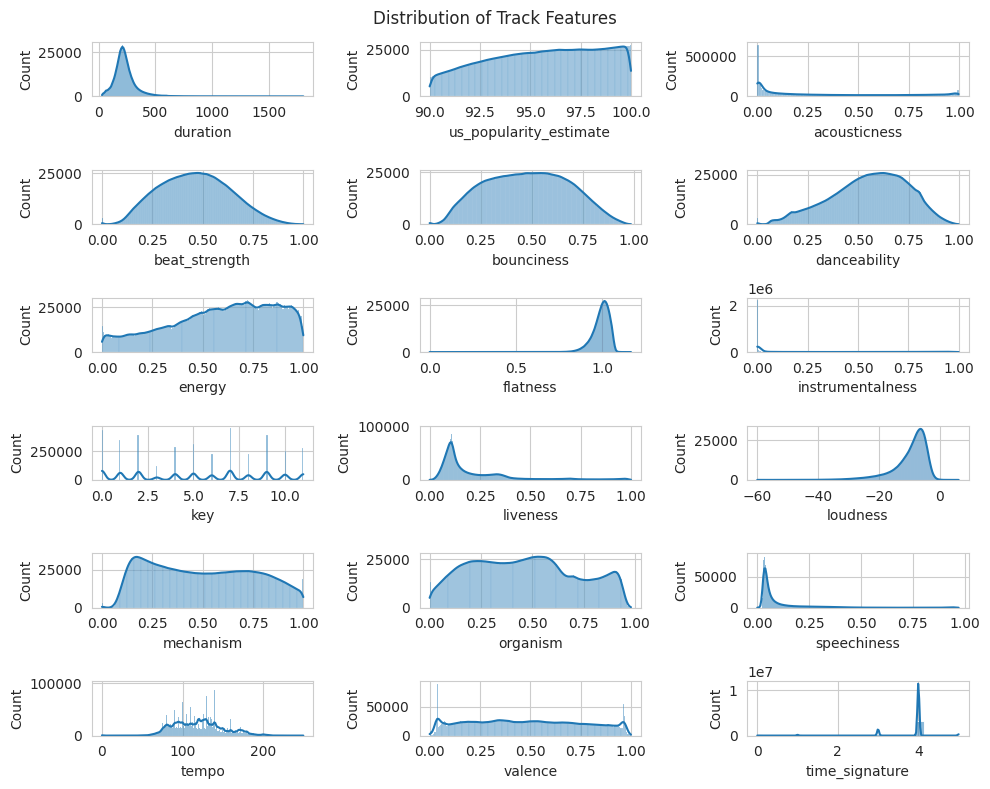

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Select the features where it may be useful to see the distribution
features_dist_cols = ['duration', 'us_popularity_estimate', 'acousticness', 'beat_strength', 'bounciness', 'danceability', 'energy', 'flatness', 'instrumentalness', 'key', 'liveness', 'loudness', 'mechanism', 'organism', 'speechiness', 'tempo', 'valence', 'time_signature']

# Subplots to show a grid of feature distributions
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(10, 8))
fig.suptitle("Distribution of Track Features")

for i, col in enumerate(features_dist_cols):
  ax=axes.flatten()[i]
  sns.histplot(track_features_df[col], ax=ax, kde=True)

plt.tight_layout()
plt.show()

**Session Log Features**

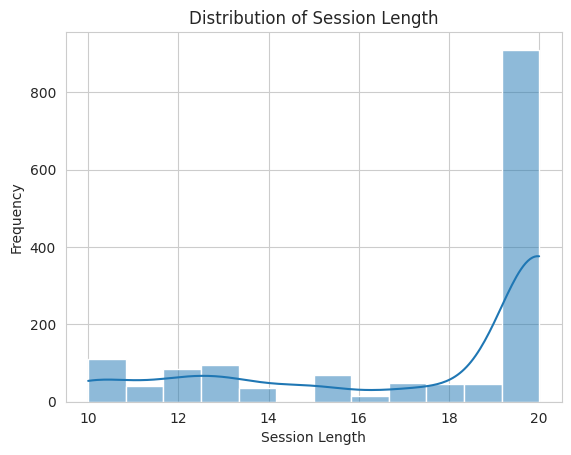

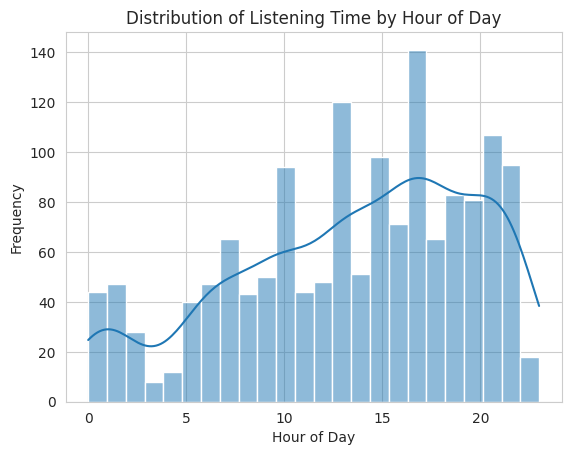

In [10]:
# Distribution of session length
sns.histplot(listen_log_df['session_length'], kde=True)
plt.title('Distribution of Session Length')
plt.xlabel('Session Length')
plt.ylabel('Frequency')
plt.show()

# Distribution of hour of day
sns.histplot(listen_log_df['hour_of_day'], bins=24, kde=True)
plt.title('Distribution of Listening Time by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.show()

Skip Rate: 0.49


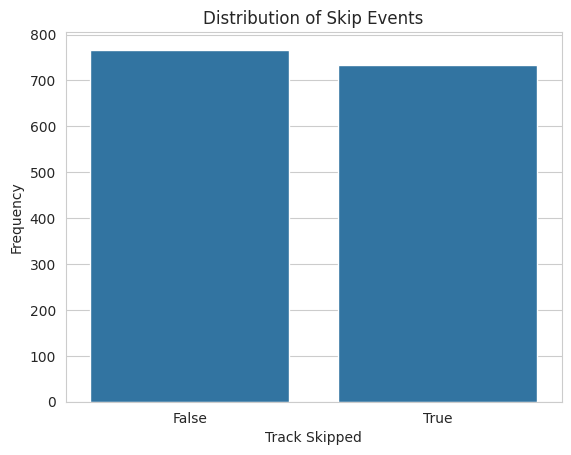

In [11]:
# Distribution of tracks skipped
skip_rate = listen_log_df['skip_2'].mean()
print(f'Skip Rate: {skip_rate:.2f}')

sns.countplot(x='skip_2', data=listen_log_df)
plt.title('Distribution of Skip Events')
plt.xlabel('Track Skipped')
plt.ylabel('Frequency')
plt.show()

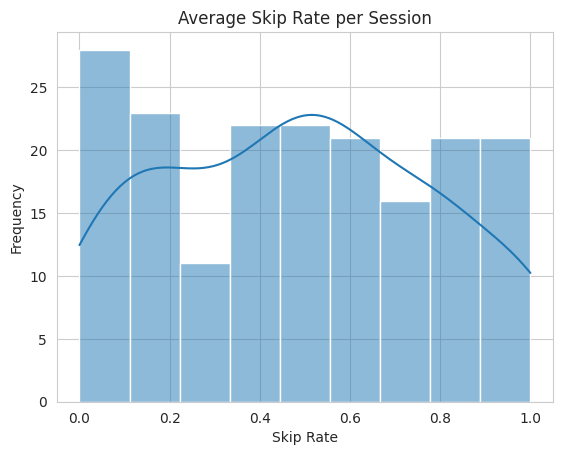

In [12]:
# Investigate average skips per session
session_skip_rate = listen_log_df.groupby('session_id')['skip_2'].mean()

sns.histplot(session_skip_rate, kde=True)
plt.title('Average Skip Rate per Session')
plt.xlabel('Skip Rate')
plt.ylabel('Frequency')
plt.show()

In [13]:
# Investigate skip rates by context type, session length, shuffle selection, and song start reason
avg_skip_by_context = listen_log_df.groupby('context_type')['skip_2'].mean()
print(avg_skip_by_context, '\n')

avg_skip_by_sesslen = listen_log_df.groupby('session_length')['skip_2'].mean()
print(avg_skip_by_sesslen, '\n')

avg_skip_by_shuffle = listen_log_df.groupby('hist_user_behavior_is_shuffle')['skip_2'].mean()
print(avg_skip_by_shuffle, '\n')

avg_skip_by_reason = listen_log_df.groupby('hist_user_behavior_reason_start')['skip_2'].mean()
print(avg_skip_by_reason)

context_type
catalog                  0.401840
charts                   0.344828
editorial_playlist       0.506964
personalized_playlist    0.476190
radio                    0.485149
user_collection          0.541267
Name: skip_2, dtype: float64 

session_length
10    0.427273
11    0.475000
12    0.380952
13    0.468750
14    0.457143
15    0.457143
16    0.812500
17    0.562500
18    0.488889
19    0.543478
20    0.500000
Name: skip_2, dtype: float64 

hist_user_behavior_is_shuffle
False    0.445672
True     0.601449
Name: skip_2, dtype: float64 

hist_user_behavior_reason_start
appload       0.516129
backbtn       0.666667
clickrow      0.378238
fwdbtn        0.730253
playbtn       0.400000
remote        0.000000
trackdone     0.177291
trackerror    0.500000
Name: skip_2, dtype: float64


<ipython-input-14-61b9d13a12af>:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
<ipython-input-14-61b9d13a12af>:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
<ipython-input-14-61b9d13a12af>:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)
<ipython-input-14-61b9d13a12af>:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45)


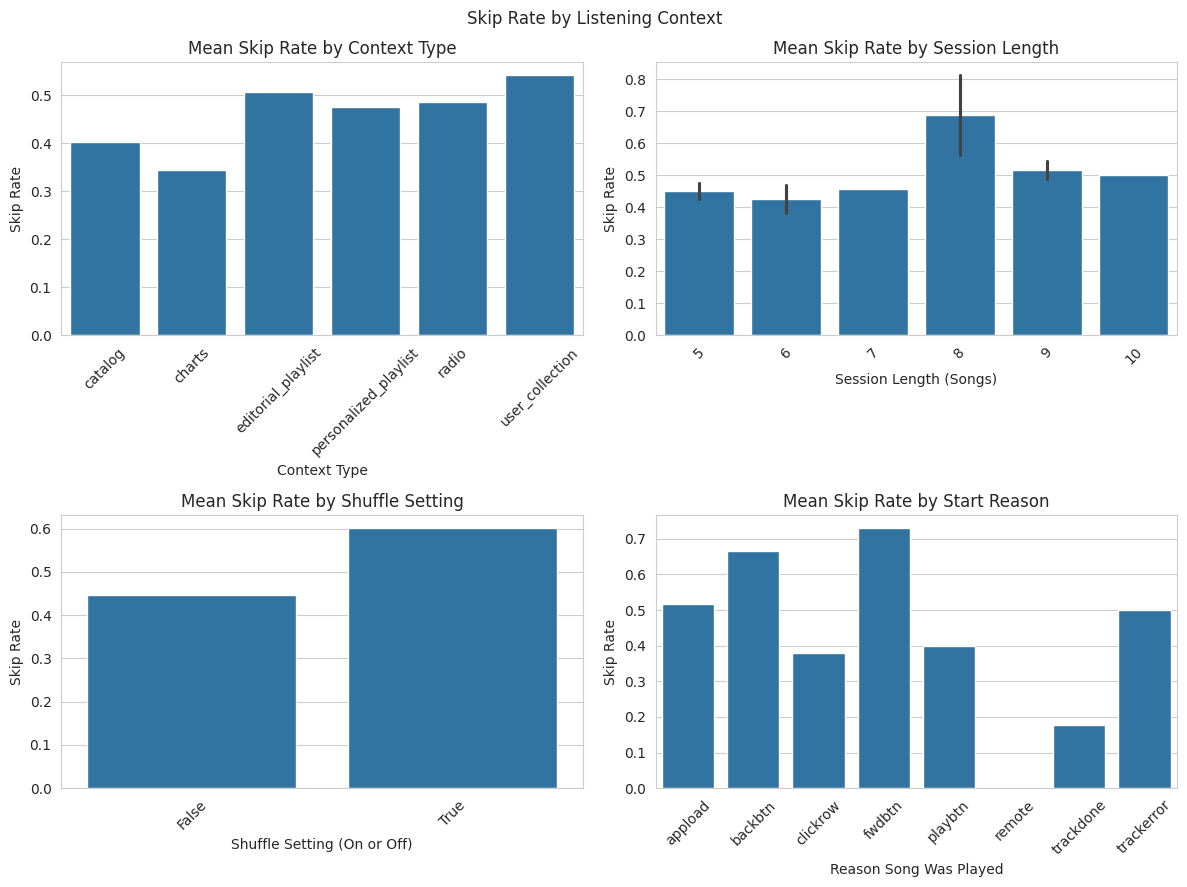

In [14]:
# Plot skip rate vs listening context feature

# Convert the Series objects to dataframes
context_skip_df = avg_skip_by_context.reset_index()
context_skip_df.columns = ['context_type', 'skip_rate']

sesslen_df = avg_skip_by_sesslen.reset_index()
sesslen_df.columns = ['session_length', 'skip_rate']

is_shuffle_df = avg_skip_by_shuffle.reset_index()
is_shuffle_df.columns = ['is_shuffle', 'skip_rate']

reason_start_df = avg_skip_by_reason.reset_index()
reason_start_df.columns = ['reason_start', 'skip_rate']

# Create subplots for each bar chart
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
fig.suptitle("Skip Rate by Listening Context")

# Mean Skip Rate by Context Type plot
ax1 = sns.barplot(x='context_type', y='skip_rate', data=context_skip_df, ax=axes[0][0])
ax1.set_title('Mean Skip Rate by Context Type')
ax1.set_xlabel('Context Type')
ax1.set_ylabel('Skip Rate')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

sesslen_df['sess_len_adjusted'] = sesslen_df['session_length'] // 2

# Mean Skip Rate by Session Length plot
ax2 = sns.barplot(x='sess_len_adjusted', y='skip_rate', data=sesslen_df, ax=axes[0][1])
ax2.set_title('Mean Skip Rate by Session Length')
ax2.set_xlabel('Session Length (Songs)')
ax2.set_ylabel('Skip Rate')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

# Mean Skip Rate by Shuffle Setting
ax3 = sns.barplot(x='is_shuffle', y='skip_rate', data=is_shuffle_df, ax=axes[1][0])
ax3.set_title('Mean Skip Rate by Shuffle Setting')
ax3.set_xlabel('Shuffle Setting (On or Off)')
ax3.set_ylabel('Skip Rate')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)

# Mean Skip Rate by Start Reason
ax4 = sns.barplot(x='reason_start', y='skip_rate', data=reason_start_df, ax=axes[1][1])
ax4.set_title('Mean Skip Rate by Start Reason')
ax4.set_xlabel('Reason Song Was Played')
ax4.set_ylabel('Skip Rate')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

**Correlation between listening context features and skip rate**

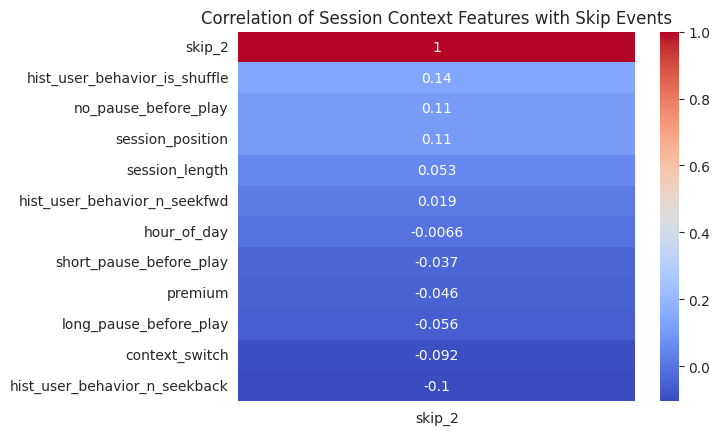

In [15]:
correlation_matrix = listen_log_df[['skip_2', 'hour_of_day', 'premium', 'session_position', 'session_length', 'context_switch', 'no_pause_before_play',
                                  'short_pause_before_play', 'long_pause_before_play', 'hist_user_behavior_n_seekfwd', 'hist_user_behavior_n_seekback',
                                  'hist_user_behavior_is_shuffle']].corr()

# Filter for only correlations with skip_2
skip_session_correlation = correlation_matrix[['skip_2']].sort_values(by='skip_2', ascending=False)
sns.heatmap(skip_session_correlation, annot=True, cmap='coolwarm')
plt.title('Correlation of Session Context Features with Skip Events')
plt.show()

**Correlation of skip events with audio content features**

In [16]:
# Merge datasets so skip event and audio features are together
merged_df = listen_log_df.merge(track_features_df, left_on='track_id_clean', right_on='track_id', how='left')

In [17]:
# List correlation columns - acoustic vectors are left out as they are not explainable for an NLP task
correlation_columns = ['skip_2', 'duration', 'us_popularity_estimate', 'acousticness', 'beat_strength', 'bounciness',
                       'danceability', 'dyn_range_mean', 'energy', 'flatness', 'instrumentalness', 'key', 'liveness',
                       'loudness', 'mechanism', 'organism', 'speechiness', 'tempo', 'time_signature', 'valence']

In [18]:
merged_df.head()

,session_id,session_position,session_length,track_id_clean,skip_1,skip_2,skip_3,not_skipped,context_switch,no_pause_before_play,...,time_signature,valence,acoustic_vector_0,acoustic_vector_1,acoustic_vector_2,acoustic_vector_3,acoustic_vector_4,acoustic_vector_5,acoustic_vector_6,acoustic_vector_7
0,1_0000015a-8bee-425e-bc96-25042a1a1cab,1,20,t_f56065b2-b26f-4080-a121-ff3bf5d25fd6,False,False,False,True,0,0,...,4,0.190213,-0.779325,0.360133,0.250115,0.018534,-0.366497,0.058069,-0.385181,0.285800
1,1_0000015a-8bee-425e-bc96-25042a1a1cab,2,20,t_447a276d-5b3d-44cf-bcbe-834ad91e7b72,False,False,True,False,0,1,...,4,0.221846,-0.290517,0.363159,0.265772,-0.320784,-0.423837,0.250794,-0.096704,0.329703
2,1_0000015a-8bee-425e-bc96-25042a1a1cab,3,20,t_07a8a863-2f51-4e64-ae3c-2fac451a0651,False,False,True,False,0,1,...,4,0.726676,-0.742573,0.469393,0.454672,-0.064590,-0.365286,0.159237,-0.296775,0.045975
3,1_0000015a-8bee-425e-bc96-25042a1a1cab,4,20,t_d2a13f32-05a8-4f7b-8633-4ed8a74ca560,False,False,True,False,0,1,...,4,0.263622,-0.321003,0.323931,0.256003,-0.233509,-0.512740,0.229690,0.013933,0.465884
4,1_0000015a-8bee-425e-bc96-25042a1a1cab,5,20,t_0368bff8-85c0-4162-b1ca-18c526b14d3a,False,False,True,False,0,1,...,4,0.587044,-0.908186,0.414644,0.278869,0.035310,-0.321306,0.031686,-0.512264,0.183649


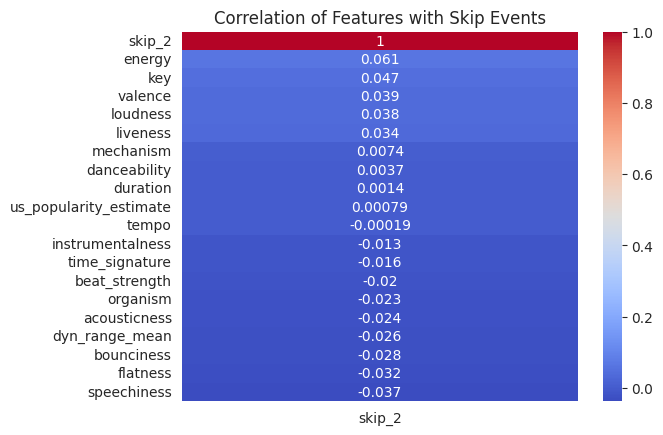

In [19]:
corr_matrix = merged_df[correlation_columns].corr()

# Include only correlations with skip_2
skip_correlations = corr_matrix[['skip_2']].sort_values(by='skip_2', ascending=False)

sns.heatmap(skip_correlations, annot=True, cmap='coolwarm')
plt.title('Correlation of Features with Skip Events')
plt.show()